# Klasifikasi Rimpang — BASELINE
**Preprocessing:** Tidak ada (hanya grayscale untuk GLCM)

---
**Cara pakai file ini sebagai template:**
1. Copy file ini, rename sesuai eksperimen (misal `p1_grayscale.ipynb`)
2. Ganti `EXP_NAME` di Cell 2
3. Ganti isi fungsi `preprocess()` di Cell 3
4. Jalankan semua cell dari atas

In [1]:
# Cell 1 — Import
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from library import (
    load_images, extract_glcm_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


In [2]:
# Cell 2 — Konfigurasi
# ⚠️ GANTI INI sesuai eksperimenmu
EXP_NAME = 'P1_Grayscale'

In [3]:
def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray = manual_bgr_to_grayscale(resized)
    eq = manual_histogram_equalization(gray)
    return eq

Total gambar loaded: 630


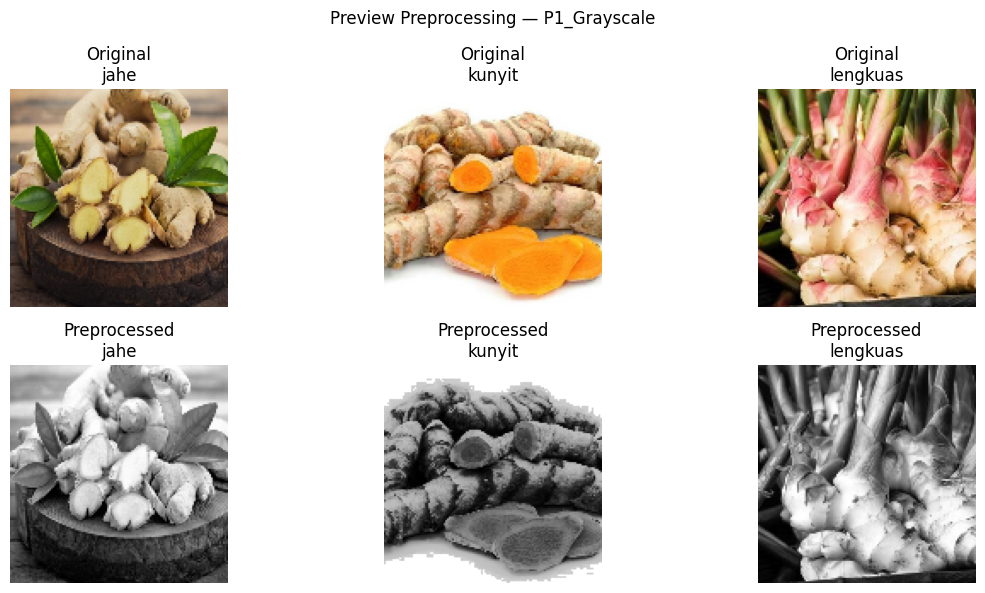

In [4]:
# Cell 4 — Load & Preview
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

In [5]:
# Cell 5 — Ekstraksi Fitur GLCM
X = np.array([extract_glcm_features(preprocess(img.copy())) for img in images])
le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 24)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P1_Grayscale.csv


In [6]:
# Cell baru — tambahkan antara Cell 5 dan Cell 6
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit HANYA dari train
X_test = scaler.transform(X_test)        # apply ke test (no fit)

Train: 504 | Test: 126
P1_Grayscale | KNN → 47.62%
              precision    recall  f1-score   support

        jahe       0.53      0.57      0.55        42
      kunyit       0.43      0.48      0.45        42
    lengkuas       0.47      0.38      0.42        42

    accuracy                           0.48       126
   macro avg       0.48      0.48      0.47       126
weighted avg       0.48      0.48      0.47       126



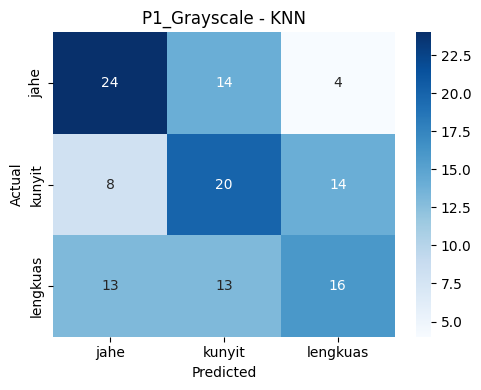

P1_Grayscale | SVM → 50.79%
              precision    recall  f1-score   support

        jahe       0.59      0.69      0.64        42
      kunyit       0.48      0.29      0.36        42
    lengkuas       0.44      0.55      0.49        42

    accuracy                           0.51       126
   macro avg       0.50      0.51      0.49       126
weighted avg       0.50      0.51      0.49       126



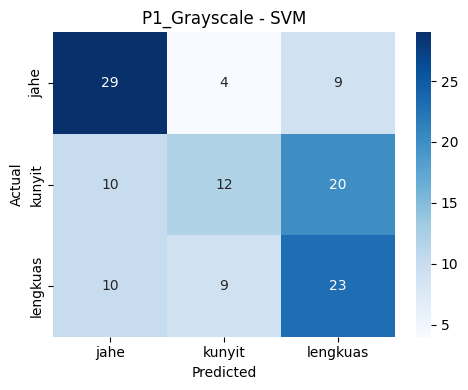

P1_Grayscale | RF → 51.59%
              precision    recall  f1-score   support

        jahe       0.61      0.55      0.57        42
      kunyit       0.48      0.55      0.51        42
    lengkuas       0.47      0.45      0.46        42

    accuracy                           0.52       126
   macro avg       0.52      0.52      0.52       126
weighted avg       0.52      0.52      0.52       126



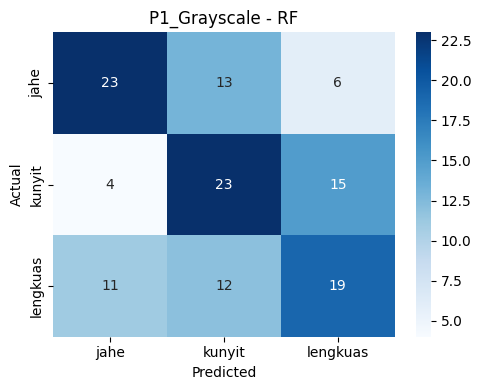


Hasil disimpan ke output/hasil_P1_Grayscale.csv
     Eksperimen Model  Akurasi
0  P1_Grayscale   KNN    47.62
1  P1_Grayscale   SVM    50.79
2  P1_Grayscale    RF    51.59


In [7]:
# Cell 6 — Training & Evaluasi
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# ) // hapus train_test_split yang duplikat di Cell 6

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)